#### Formal equations

For timestep $t$, with concatenated input $z_t = [h_{t-1}, x_t]$, an LSTM cell typically computes:

1. Forget gate:

$$
f_t = \sigma(W_f z_t + b_f)
$$
2. Input gate:

$$
i_t = \sigma(W_i z_t + b_i)
$$
3. Candidate cell:

$$
\tilde{c}_t = \tanh(W_c z_t + b_c)
$$
4. New cell state:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$
5. Output gate:

$$
o_t = \sigma(W_o z_t + b_o)
$$
6. New hidden state:

$$
h_t = o_t \odot \tanh(c_t)
$$

Here $\sigma$ is sigmoid, $\tanh$ is hyperbolic tangent, and $\odot$ is element‑wise multiplication.




#### Forget gate in detail

The **forget gate** decides what information in the previous cell state should be erased.

- Inputs: $h_{t-1}$ and $x_t$, concatenated.[^4][^5]
- Operation: pass through a sigmoid layer with its own weights and biases to produce $f_t$.
- Use: multiply $f_t$ element‑wise with $c_{t-1}$; values near 0 delete components, values near 1 keep them.

Intuition: if the current word indicates a topic change in a sentence, the forget gate can drop the old topic information from memory.


#### Input gate and candidate cell

The **input gate** controls what *new* information is written into the cell, and the candidate cell $\tilde{c}_t$ proposes what that new information could be.[^1][^4][^6]

This happens in two parallel steps:

1. **Candidate creation**:
    - Concatenate $h_{t-1}$ and $x_t$, pass through a tanh layer to produce $\tilde{c}_t$ with values in $[-1, 1]$.
    - Positive values suggest increasing certain memory components; negative values suggest decreasing them.
2. **Input gate computation**:
    - Same inputs $z_t$, through a sigmoid layer to produce $i_t$ in $[0,1]$.
    - This vector decides which parts of $\tilde{c}_t$ to accept.

Then the cell update term from new information is $i_t \odot \tilde{c}_t$, which is added to the (possibly partially forgotten) old cell state.


#### Output gate and hidden state

The **output gate** decides what part of the internal cell state becomes visible as the hidden state $h_t$.

- First, compute a candidate output by applying tanh to the updated cell state: $\tanh(c_t)$, which squashes it into $[-1, 1]$.
- Next, compute the output gate vector:

$$
o_t = \sigma(W_o z_t + b_o)
$$

using $h_{t-1}$ and $x_t$.
- Finally, form the hidden state:

$$
h_t = o_t \odot \tanh(c_t)
$$

so the gate selects which components of the internal memory to emit.

This hidden state is both the output at timestep $t$ and one of the inputs at timestep $t+1$.

***


### class torch.nn.LSTM(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0.0, bidirectional=False, proj_size=0, device=None, dtype=None)

***


#### First Try

In [21]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- 1. Configuration ----
SEQ_LEN = 5        # length of input sequence
MAX_NUM = 50       # numbers range from 0 to MAX_NUM
NUM_SEQUENCES = 1000
BATCH_SIZE = 32
HIDDEN_SIZE = 32
NUM_EPOCHS = 30
LR = 0.01
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


# ---- 2. Create synthetic dataset ----
# We create sequences of consecutive integers.
# Example: [0,1,2,3,4] -> 5, [1,2,3,4,5] -> 6, etc.

def generate_sequences(num_sequences, seq_len, max_num):
    X_list = []
    y_list = []
    for _ in range(num_sequences):
        # choose a random starting number so that we have room for target
        start = np.random.randint(0, max_num - seq_len - 1)
        seq = np.arange(start, start + seq_len + 1, dtype=np.float32)
        X_list.append(seq[:-1])  # first seq_len numbers
        y_list.append(seq[-1])   # next number as target
    X = np.stack(X_list)  # (N, seq_len)
    y = np.stack(y_list)  # (N,)
    return X, y

X, y = generate_sequences(NUM_SEQUENCES, SEQ_LEN, MAX_NUM)

# Normalize a bit so values are in a nicer range
X = X / MAX_NUM
y = y / MAX_NUM


class SequenceDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, seq_len), y: (N,)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        # Return shape: (seq_len, 1) for input (time, features)
        seq = self.X[idx].unsqueeze(-1)  # (seq_len,) -> (seq_len, 1)
        target = self.y[idx]             # scalar
        return seq, target


dataset = SequenceDataset(X, y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Dataset size: {len(dataset)}, Number of batches: {len(dataloader)}")

Using device: cuda
Dataset size: 1000, Number of batches: 32


In [22]:
class LSTM_1(nn.Module):
    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x):
        # x: (seq_len, batch, input_size)
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(DEVICE)
        out, (hn, cn) = self.lstm(x, (h0, c0))  # out: (batch, seq_len, hidden_size)
        last_hidden = out[:, -1, :] 
        prediction = self.fc(last_hidden)
        return prediction.squeeze(-1)

In [23]:
model = LSTM_1().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for seq_batch, target_batch in dataloader:
        seq_batch, target_batch = seq_batch.to(DEVICE), target_batch.to(DEVICE)

        optimizer.zero_grad()
        predictions = model(seq_batch)
        loss = criterion(predictions, target_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * seq_batch.size(0)

    avg_loss = total_loss / len(dataset)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.4f}")

    

Epoch [5/30], Loss: 0.0000
Epoch [10/30], Loss: 0.0000
Epoch [15/30], Loss: 0.0000
Epoch [20/30], Loss: 0.0000
Epoch [25/30], Loss: 0.0000
Epoch [30/30], Loss: 0.0000


In [24]:
model.eval()

x = [2, 4, 6, 8, 10]
x_norm = np.array(x, dtype=np.float32) / MAX_NUM

with torch.no_grad():
    test_seq = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(DEVICE)
    prediction = model(test_seq)

    pred_norm = prediction.item()
    pred_actual = pred_norm * MAX_NUM

    print(f"Input sequence: {x}")
    print(f"Predicted next number (normalized): {pred_norm:.4f}")
    print(f"Predicted next number (original scale): {pred_actual:.4f}")
    print("Expected:", 12)

Input sequence: [2, 4, 6, 8, 10]
Predicted next number (normalized): 0.1877
Predicted next number (original scale): 9.3857
Expected: 12


***
#### Predicting Characters

In [27]:
import torch
import torch.nn as nn
import numpy as np

import urllib.request

# 1. Download the Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"
urllib.request.urlretrieve(url, filename)

# 2. Read the text file into a string
with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Length of dataset in characters: {len(text)}")

# 3. For a quick 2-hour learning session, let's slice the first 10,000 characters. 
# (Training on the full 1 million characters takes much longer!)
text = text[:10000]

# 4. Build the vocabulary exactly as we did before
chars = list(set(text))
vocab_size = len(chars)

char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Vocabulary size: {vocab_size} unique characters")

Length of dataset in characters: 1115394
Vocabulary size: 57 unique characters


In [28]:
def text_to_onehot(string):
    tensor = torch.zeros(len(string), vocab_size)
    for i, char in enumerate(string):
        tensor[i, char_to_ix[char]] = 1.0
    return tensor

def text_to_indices(string):
    """Converts a string to a tensor of integer indices."""
    indices = [char_to_ix[char] for char in string]
    return torch.tensor(indices, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [32]:
class LSTM_2(nn.Module):
    def __init__(self, input_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x: [batch, seq_len, vocab_size] if one-hot encoded
        out, hidden = self.lstm(x, hidden)         # [batch, seq_len, hidden_size]
        out = self.fc(out)                         # [batch, seq_len, vocab_size]
        return out, hidden

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# =========================================================
# Assumes these already exist:
# text, vocab_size, text_to_onehot, text_to_indices, device
# =========================================================

# ----------------------------
# Hyperparameters
# ----------------------------
hl = 16
num_epoch = 20
batch_size = 64
seq_len = 20
lr = 0.01

# ----------------------------
# LSTM model for character prediction
# ----------------------------
class LSTM_2(nn.Module):
    def __init__(self, input_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)   # out: (batch, seq_len, hidden_size)
        out = self.fc(out)                   # out: (batch, seq_len, vocab_size)
        return out, hidden

# ----------------------------
# Build dataset
# ----------------------------
samples = []
for i in range(len(text) - seq_len):
    input_seq = text[i:i+seq_len]
    target_seq = text[i+1:i+seq_len+1]

    input_tensor = text_to_onehot(input_seq)     # (seq_len, vocab_size)
    target_tensor = text_to_indices(target_seq)  # (seq_len,)

    samples.append((input_tensor, target_tensor))

# ----------------------------
# Train/Validation split
# ----------------------------
train_size = int(0.8 * len(samples))
val_size = len(samples) - train_size

train_dataset, val_dataset = random_split(samples, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# ----------------------------
# Model, loss, optimizer
# ----------------------------
model = LSTM_2(
    input_size=vocab_size,
    hidden_size=hl,
    vocab_size=vocab_size,
    num_layers=1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

# ----------------------------
# Metric storage
# ----------------------------
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ----------------------------
# Gate tracking setup
# PyTorch LSTM gate order: i, f, g, o
# i = input gate
# f = forget gate
# g = cell gate
# o = output gate
# ----------------------------
gate_names = ["input", "forget", "cell", "output"]

def split_lstm_gates(param):
    return torch.chunk(param, 4, dim=0)

gate_weight_norm_history = {}
gate_weight_change_history = {}

for gate in gate_names:
    for prefix in ["W_ih", "W_hh", "b_ih", "b_hh"]:
        gate_weight_norm_history[f"{prefix}_{gate}"] = []
        gate_weight_change_history[f"{prefix}_{gate}"] = []

prev_lstm_params = {
    "weight_ih_l0": model.lstm.weight_ih_l0.detach().clone(),
    "weight_hh_l0": model.lstm.weight_hh_l0.detach().clone(),
    "bias_ih_l0": model.lstm.bias_ih_l0.detach().clone(),
    "bias_hh_l0": model.lstm.bias_hh_l0.detach().clone(),
}

# ----------------------------
# Training loop
# ----------------------------
for epoch in range(num_epoch):
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs = inputs.to(device)   # (batch, seq_len, vocab_size)
        labels = labels.to(device)   # (batch, seq_len)

        optimizer.zero_grad()

        outputs, hidden = model(inputs)

        outputs_flat = outputs.reshape(-1, vocab_size)   # (batch*seq_len, vocab_size)
        labels_flat = labels.reshape(-1)                 # (batch*seq_len,)

        loss = criterion(outputs_flat, labels_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()

        running_train_loss += loss.item()

        preds = torch.argmax(outputs_flat, dim=1)
        train_correct += (preds == labels_flat).sum().item()
        train_total += labels_flat.size(0)

    epoch_train_loss = running_train_loss / len(trainloader)
    epoch_train_acc = train_correct / train_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs, hidden = model(inputs)

            outputs_flat = outputs.reshape(-1, vocab_size)
            labels_flat = labels.reshape(-1)

            loss = criterion(outputs_flat, labels_flat)
            running_val_loss += loss.item()

            preds = torch.argmax(outputs_flat, dim=1)
            val_correct += (preds == labels_flat).sum().item()
            val_total += labels_flat.size(0)

    epoch_val_loss = running_val_loss / len(valloader)
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # ----------------------------
    # Track gate-wise weights and biases per epoch
    # ----------------------------
    with torch.no_grad():
        current_params = {
            "weight_ih_l0": model.lstm.weight_ih_l0,
            "weight_hh_l0": model.lstm.weight_hh_l0,
            "bias_ih_l0": model.lstm.bias_ih_l0,
            "bias_hh_l0": model.lstm.bias_hh_l0,
        }

        for param_name, prefix in [
            ("weight_ih_l0", "W_ih"),
            ("weight_hh_l0", "W_hh"),
            ("bias_ih_l0", "b_ih"),
            ("bias_hh_l0", "b_hh"),
        ]:
            current_gates = split_lstm_gates(current_params[param_name])
            prev_gates = split_lstm_gates(prev_lstm_params[param_name])

            for idx, gate in enumerate(gate_names):
                gate_weight_norm_history[f"{prefix}_{gate}"].append(
                    current_gates[idx].norm().item()
                )
                gate_weight_change_history[f"{prefix}_{gate}"].append(
                    (current_gates[idx] - prev_gates[idx]).abs().mean().item()
                )

        for k in prev_lstm_params:
            prev_lstm_params[k] = current_params[k].detach().clone()

    print(
        f"Epoch {epoch+1}/{num_epoch} | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )



Epoch 1/20 | Train Loss: 3.0094 | Train Acc: 0.2069 | Val Loss: 2.5149 | Val Acc: 0.3013
Epoch 2/20 | Train Loss: 2.3372 | Train Acc: 0.3437 | Val Loss: 2.2103 | Val Acc: 0.3669
Epoch 3/20 | Train Loss: 2.1520 | Train Acc: 0.3835 | Val Loss: 2.0890 | Val Acc: 0.4020
Epoch 4/20 | Train Loss: 2.0468 | Train Acc: 0.4117 | Val Loss: 1.9999 | Val Acc: 0.4178
Epoch 5/20 | Train Loss: 1.9691 | Train Acc: 0.4276 | Val Loss: 1.9319 | Val Acc: 0.4366
Epoch 6/20 | Train Loss: 1.9112 | Train Acc: 0.4423 | Val Loss: 1.8846 | Val Acc: 0.4424
Epoch 7/20 | Train Loss: 1.8685 | Train Acc: 0.4514 | Val Loss: 1.8491 | Val Acc: 0.4571
Epoch 8/20 | Train Loss: 1.8353 | Train Acc: 0.4586 | Val Loss: 1.8246 | Val Acc: 0.4612
Epoch 9/20 | Train Loss: 1.8084 | Train Acc: 0.4660 | Val Loss: 1.7985 | Val Acc: 0.4659
Epoch 10/20 | Train Loss: 1.7860 | Train Acc: 0.4706 | Val Loss: 1.7798 | Val Acc: 0.4714
Epoch 11/20 | Train Loss: 1.7662 | Train Acc: 0.4763 | Val Loss: 1.7642 | Val Acc: 0.4756
Epoch 12/20 | Train

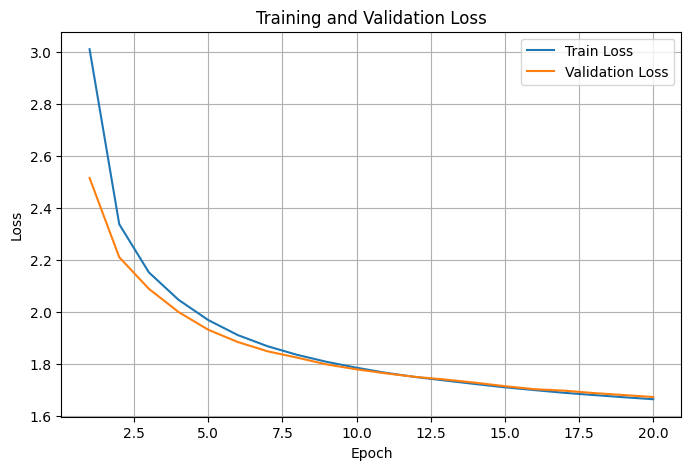

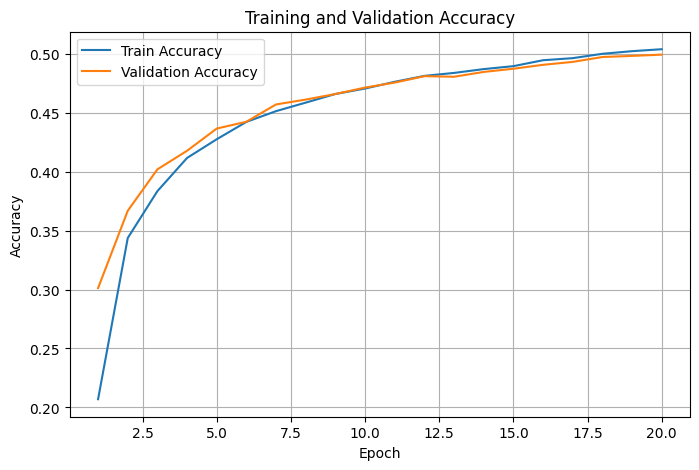

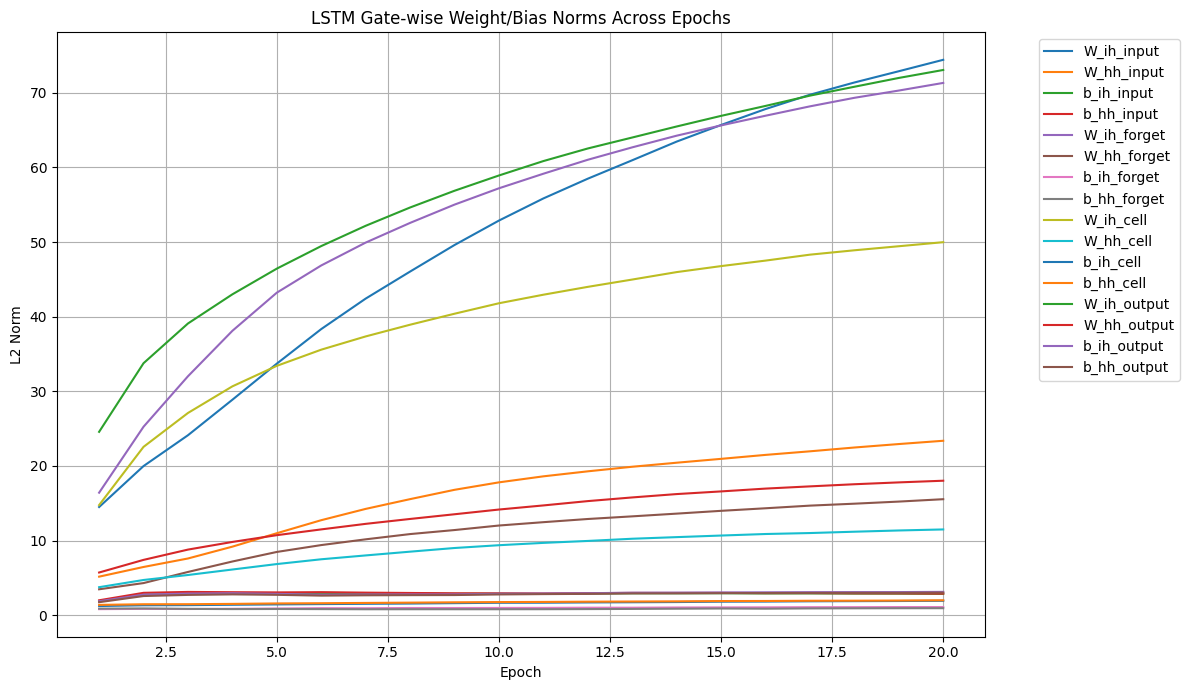

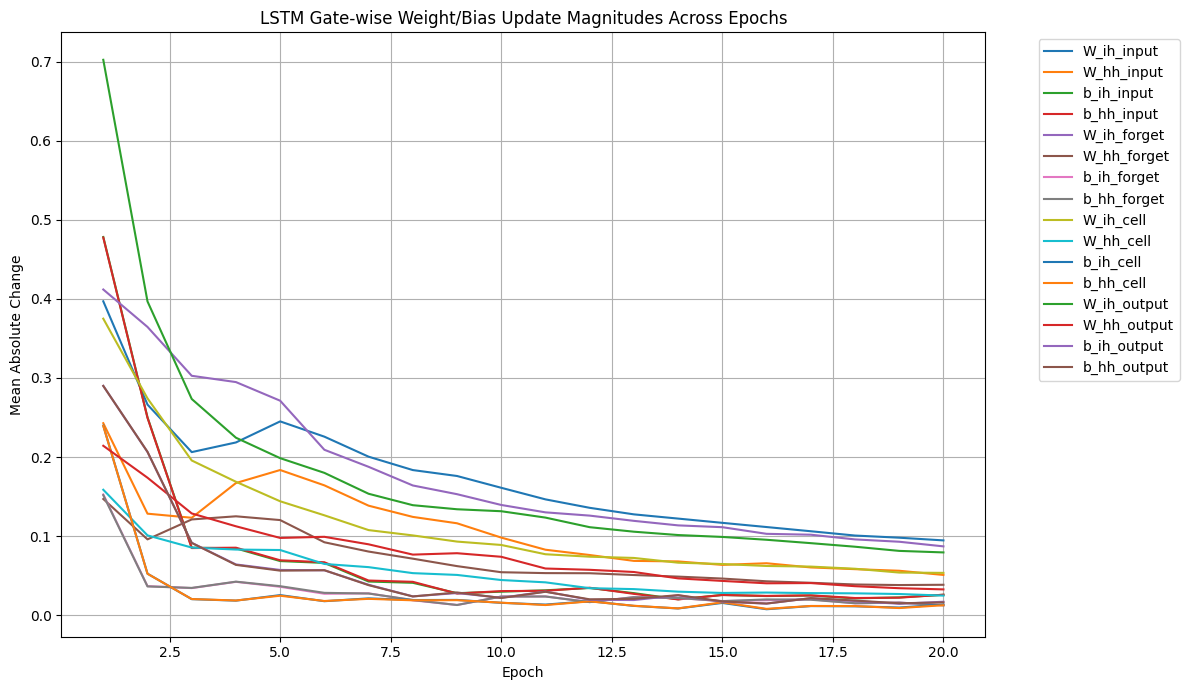

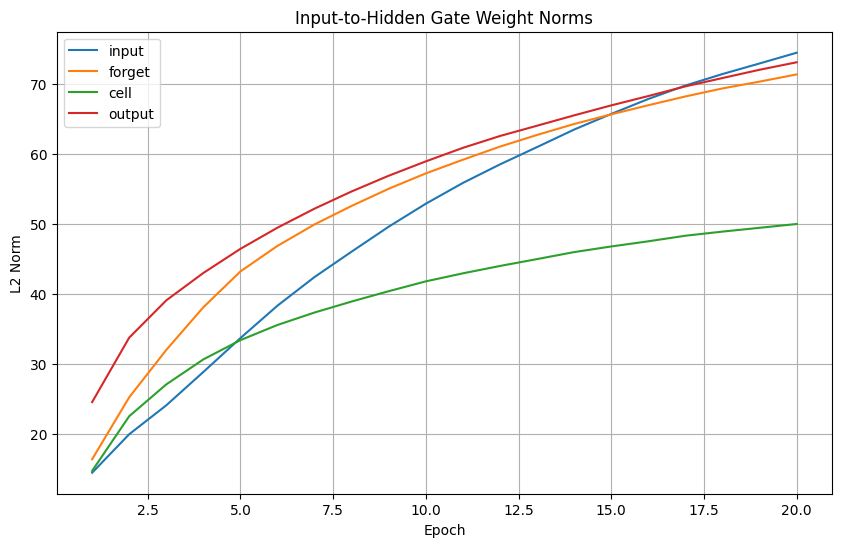

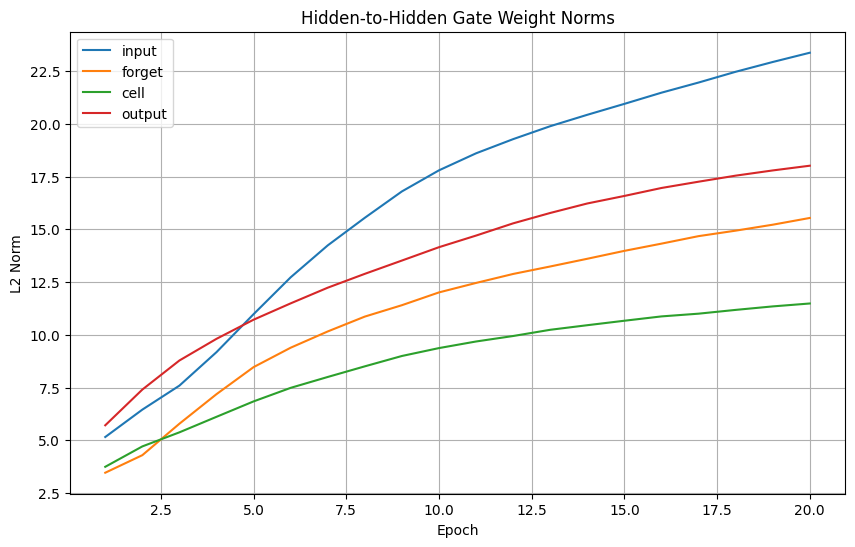

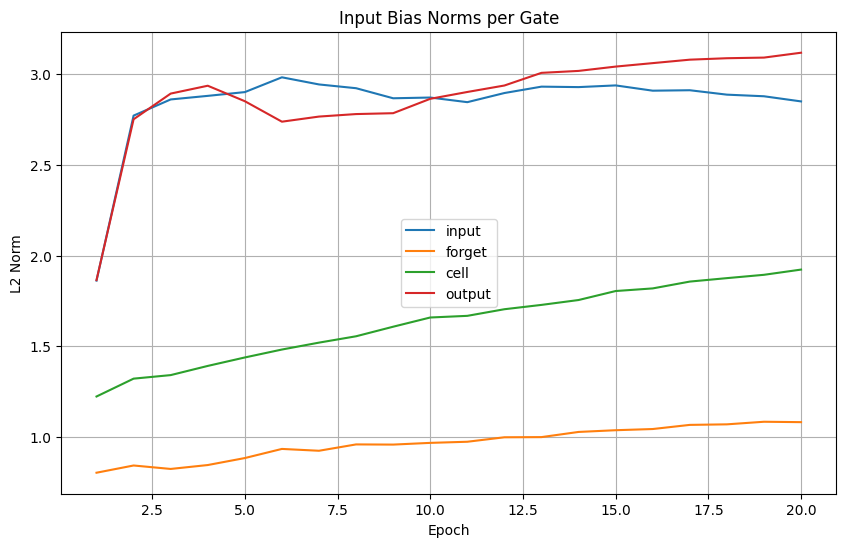

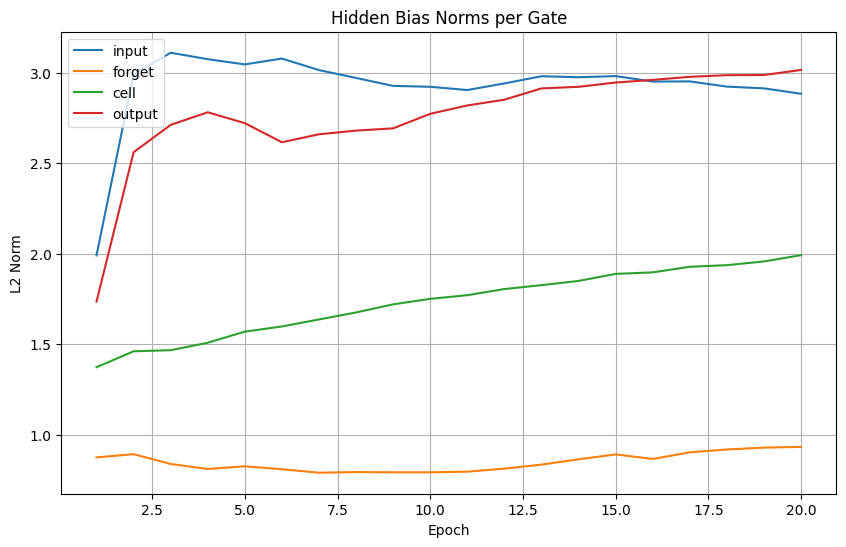

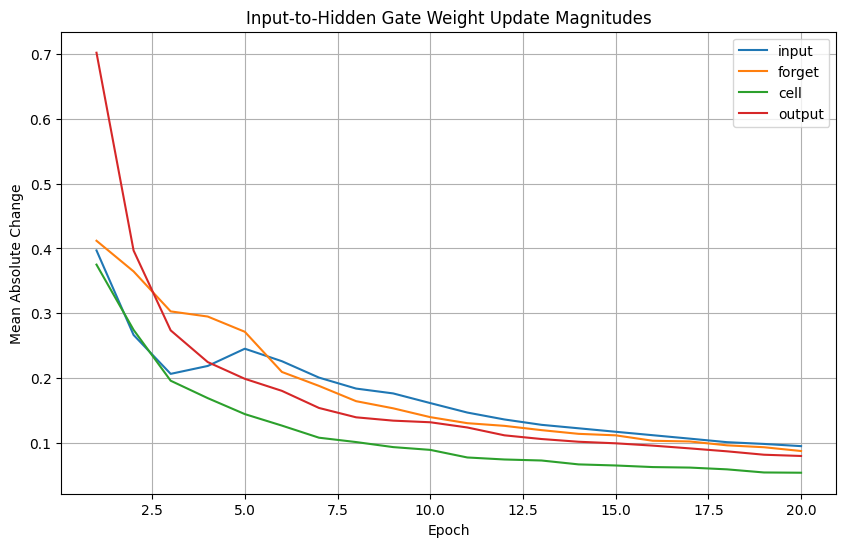

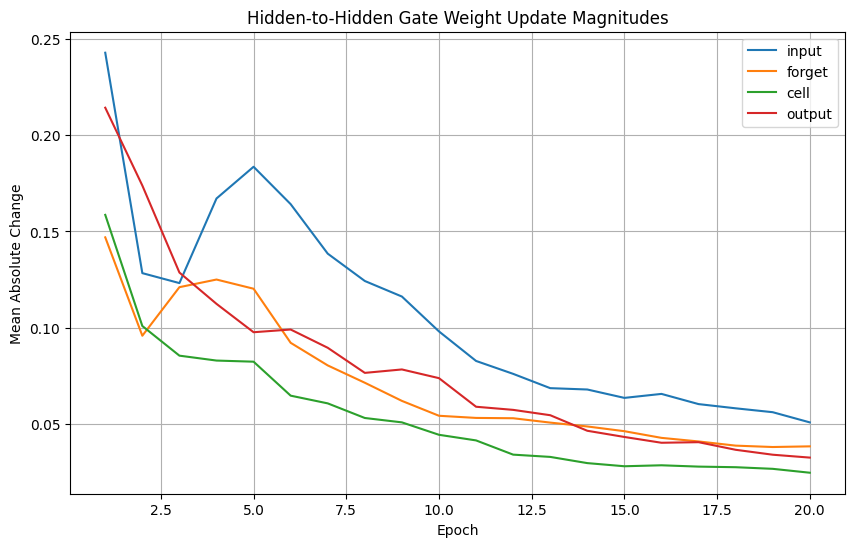

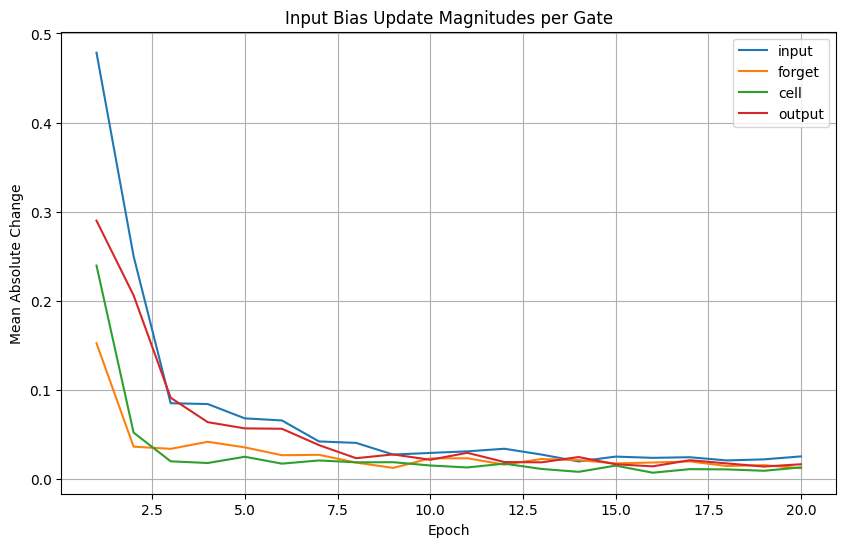

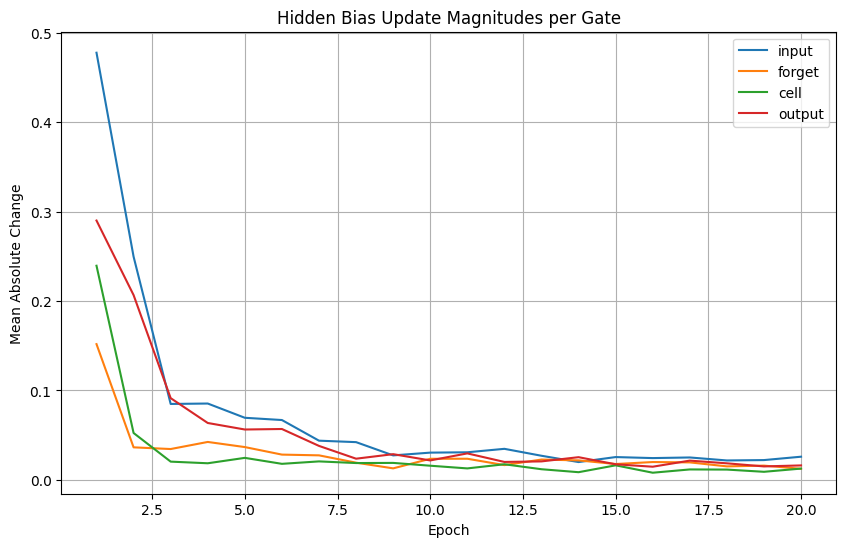

In [47]:
# =========================================================
# PLOTS
# =========================================================

# ----------------------------
# Plot Loss
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epoch + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epoch + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epoch + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epoch + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot all gate parameter norms together
# ----------------------------
plt.figure(figsize=(12, 7))
for name, values in gate_weight_norm_history.items():
    plt.plot(range(1, num_epoch + 1), values, label=name)
plt.xlabel("Epoch")
plt.ylabel("L2 Norm")
plt.title("LSTM Gate-wise Weight/Bias Norms Across Epochs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot all gate parameter changes together
# ----------------------------
plt.figure(figsize=(12, 7))
for name, values in gate_weight_change_history.items():
    plt.plot(range(1, num_epoch + 1), values, label=name)
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Change")
plt.title("LSTM Gate-wise Weight/Bias Update Magnitudes Across Epochs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot input-to-hidden gate weight norms
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_norm_history[f"W_ih_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("L2 Norm")
plt.title("Input-to-Hidden Gate Weight Norms")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot hidden-to-hidden gate weight norms
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_norm_history[f"W_hh_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("L2 Norm")
plt.title("Hidden-to-Hidden Gate Weight Norms")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot input bias norms
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_norm_history[f"b_ih_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("L2 Norm")
plt.title("Input Bias Norms per Gate")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot hidden bias norms
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_norm_history[f"b_hh_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("L2 Norm")
plt.title("Hidden Bias Norms per Gate")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot input-to-hidden gate weight changes
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_change_history[f"W_ih_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Change")
plt.title("Input-to-Hidden Gate Weight Update Magnitudes")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot hidden-to-hidden gate weight changes
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_change_history[f"W_hh_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Change")
plt.title("Hidden-to-Hidden Gate Weight Update Magnitudes")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot input bias changes
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_change_history[f"b_ih_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Change")
plt.title("Input Bias Update Magnitudes per Gate")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot hidden bias changes
# ----------------------------
plt.figure(figsize=(10, 6))
for gate in gate_names:
    plt.plot(
        range(1, num_epoch + 1),
        gate_weight_change_history[f"b_hh_{gate}"],
        label=gate
    )
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Change")
plt.title("Hidden Bias Update Magnitudes per Gate")
plt.legend()
plt.grid(True)
plt.show()

***

#### Predict Words

In [16]:
import torch
import torch.nn as nn
import numpy as np

import urllib.request

# 1. Download the Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"
urllib.request.urlretrieve(url, filename)

# 2. Read the text file into a string
with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Length of dataset in characters: {len(text)}")

# 3. For a quick 2-hour learning session, let's slice the first 10,000 characters. 
# (Training on the full 1 million characters takes much longer!)
#text = text[:10000]

# 4. Build the vocabulary exactly as we did before
words = text.lower().split()
vocab = sorted(set(words))
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for word, i in word_to_ix.items()}

print(f"Vocabulary size: {vocab_size} unique words")



Length of dataset in characters: 1115394
Vocabulary size: 23641 unique words


In [17]:
def text_to_onehot(string):
    tensor = torch.zeros(len(string), vocab_size)
    for i, word in enumerate(string):
        tensor[i, word_to_ix[word]] = 1.0
    return tensor

def words_to_indices(string):
    return torch.tensor([word_to_ix[word] for word in string], dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

class wordLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=64, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x: [batch_size, seq_len]
        x = self.embedding(x)   # [batch_size, seq_len, embed_dim]

        batch_size = x.size(0)

        if hidden is None:
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        else:
            h0, c0 = hidden

        out, (hn, cn) = self.lstm(x, (h0, c0))   # out: [batch_size, seq_len, hidden_size]
        prediction = self.fc(out)                # [batch_size, seq_len, vocab_size]

        return prediction, (hn, cn)

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# ----------------------------
# Hyperparameters
# ----------------------------
hl = 64
num_epoch = 20
batch_size = 64
seq_len = 20
lr = 0.01
embed_dim = 64

samples = []

for i in range(len(words) - seq_len):
    input_seq = words[i:i+seq_len]
    target_seq = words[i+1:i+seq_len+1]

    input_tensor = words_to_indices(input_seq)    # [seq_len]
    target_tensor = words_to_indices(target_seq)  # [seq_len]

    samples.append((input_tensor, target_tensor))

train_size = int(0.8 * len(samples))
val_size = len(samples) - train_size

train_dataset, val_dataset = random_split(samples, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [20]:
import copy
import matplotlib.pyplot as plt

# ----------------------------
# GATE TRACKING SETUP
# ----------------------------
# PyTorch always chunks LSTM weights in this exact order:
gate_names = ['Input (i)', 'Forget (f)', 'Cell (g)', 'Output (o)']
gate_weight_changes = {gate: [] for gate in gate_names}

def get_lstm_weights(model):
    # Concatenate the input-hidden and hidden-hidden weights into one matrix
    # .detach().clone() ensures we get a snapshot that isn't attached to the computational graph
    return torch.cat([
        model.lstm.weight_ih_l0.detach().clone(),
        model.lstm.weight_hh_l0.detach().clone()
    ], dim=1)




In [21]:
embed_dim = 64
hidden_size = 64

model = wordLSTM(vocab_size=vocab_size, embed_dim=embed_dim, hidden_size=hidden_size, num_layers=1).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Store the initial weights before training starts
prev_weights = get_lstm_weights(model)

for epoch in range(num_epoch):
    # ----------------------------
    # Training
    # ----------------------------
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for seq_batch, target_batch in trainloader:
        seq_batch = seq_batch.to(device)         # [batch_size, seq_len]
        target_batch = target_batch.to(device)   # [batch_size, seq_len]

        optimizer.zero_grad()

        predictions, hidden = model(seq_batch)   # [batch_size, seq_len, vocab_size]

        prediction_flat = predictions.reshape(-1, vocab_size)   # [batch_size * seq_len, vocab_size]
        labels_flat = target_batch.reshape(-1)                  # [batch_size * seq_len]

        loss = criterion(prediction_flat, labels_flat)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        preds = torch.argmax(prediction_flat, dim=1)
        train_correct += (preds == labels_flat).sum().item()
        train_total += labels_flat.size(0)

    epoch_train_loss = running_train_loss / len(trainloader)
    epoch_train_acc = train_correct / train_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for seq_batch, target_batch in valloader:
            seq_batch = seq_batch.to(device)
            target_batch = target_batch.to(device)

            predictions, hidden = model(seq_batch)

            prediction_flat = predictions.reshape(-1, vocab_size)
            labels_flat = target_batch.reshape(-1)

            loss = criterion(prediction_flat, labels_flat)
            running_val_loss += loss.item()

            preds = torch.argmax(prediction_flat, dim=1)
            val_correct += (preds == labels_flat).sum().item()
            val_total += labels_flat.size(0)

    epoch_val_loss = running_val_loss / len(valloader)
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epoch}] "
        f"| Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} "
        f"| Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

    # ----------------------------
    # MEASURE WEIGHT CHANGES
    # ----------------------------
    curr_weights = get_lstm_weights(model)
    
    # Calculate the absolute difference from the previous epoch
    weight_diff = curr_weights - prev_weights
    
    # Split the giant tensor back into the 4 individual gates
    gate_diffs = weight_diff.chunk(4, dim=0)
    
    for i, gate in enumerate(gate_names):
        # Calculate the L2 norm (magnitude) of the weight change for this specific gate
        change_magnitude = gate_diffs[i].norm().item()
        gate_weight_changes[gate].append(change_magnitude)
        
    # Set the current weights as the 'previous' weights for the next loop
    prev_weights = curr_weights

Epoch [1/20] | Train Loss: 4.8237 | Train Acc: 0.1947 | Val Loss: 3.5998 | Val Acc: 0.3162
Epoch [2/20] | Train Loss: 3.1317 | Train Acc: 0.3872 | Val Loss: 2.8835 | Val Acc: 0.4297
Epoch [3/20] | Train Loss: 2.6563 | Train Acc: 0.4670 | Val Loss: 2.5953 | Val Acc: 0.4804
Epoch [4/20] | Train Loss: 2.4330 | Train Acc: 0.5066 | Val Loss: 2.4350 | Val Acc: 0.5090
Epoch [5/20] | Train Loss: 2.2989 | Train Acc: 0.5308 | Val Loss: 2.3339 | Val Acc: 0.5277
Epoch [6/20] | Train Loss: 2.2064 | Train Acc: 0.5477 | Val Loss: 2.2548 | Val Acc: 0.5421
Epoch [7/20] | Train Loss: 2.1364 | Train Acc: 0.5606 | Val Loss: 2.1999 | Val Acc: 0.5517
Epoch [8/20] | Train Loss: 2.0789 | Train Acc: 0.5709 | Val Loss: 2.1454 | Val Acc: 0.5618
Epoch [9/20] | Train Loss: 2.0299 | Train Acc: 0.5805 | Val Loss: 2.0931 | Val Acc: 0.5730
Epoch [10/20] | Train Loss: 1.9884 | Train Acc: 0.5884 | Val Loss: 2.0624 | Val Acc: 0.5779
Epoch [11/20] | Train Loss: 1.9529 | Train Acc: 0.5951 | Val Loss: 2.0316 | Val Acc: 0.58

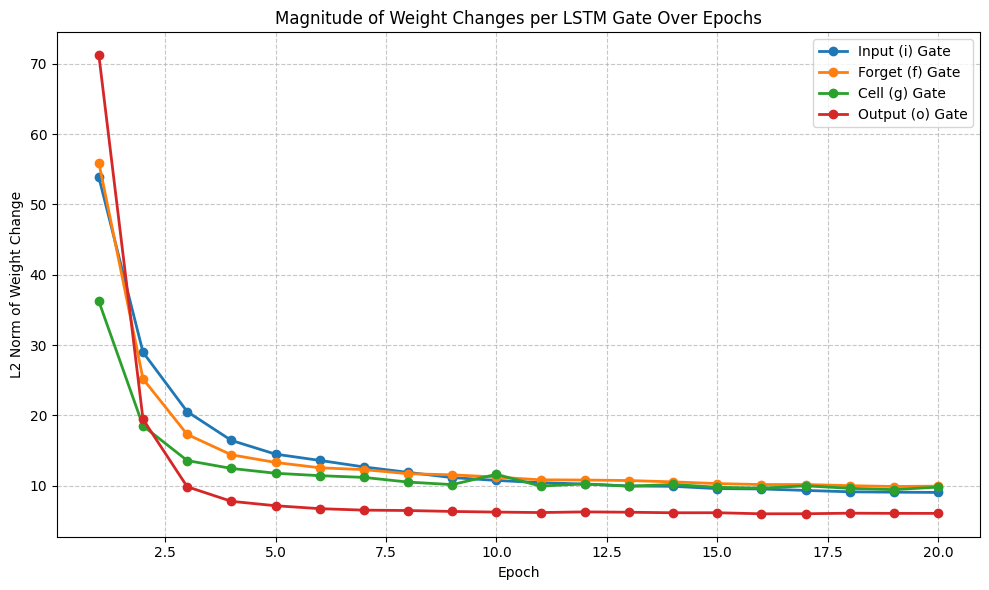

In [ ]:

# ----------------------------
# VISUALIZE GATE DYNAMICS
# ----------------------------
plt.figure(figsize=(10, 6))
epochs_range = range(1, num_epoch + 1)

for gate in gate_names:
    plt.plot(epochs_range, gate_weight_changes[gate], label=f'{gate} Gate', marker='o', linewidth=2)

plt.title('Magnitude of Weight Changes per LSTM Gate Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('L2 Norm of Weight Change')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
def generate_text(model, start_word, predict_len=10):
    model.eval()

    if start_word not in word_to_ix:
        return f"Word '{start_word}' not in vocabulary."

    current_word = start_word
    generated_words = [start_word]
    hidden = None

    with torch.no_grad():
        for _ in range(predict_len):
            current_idx = torch.tensor([[word_to_ix[current_word]]], dtype=torch.long).to(device)
            output, hidden = model(current_idx, hidden)

            predicted_index = torch.argmax(output[0, -1], dim=-1).item()
            current_word = ix_to_word[predicted_index]
            generated_words.append(current_word)

    return " ".join(generated_words)

print(generate_text(model, start_word="i", predict_len=10))

i am too young; i pray you, avoid: come. coriolanus: follow
